In [1]:
import os
print(os.listdir('/content'))

['.config', 'sample_data']


In [2]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [3]:
import pandas as pd
import os

# define the folder where your data is stored
my_path = '/content/drive/MyDrive/Bellabeat_Case_Study_Data'

# join the folder path with the specific file name
file_to_load = os.path.join(my_path,'dailyActivity_merged.csv')

# load data into the dataframe called df_activity
df_activity = pd.read_csv(file_to_load)

# success check look at the first five rows
print("data loaded successfully!")
df_activity.head()

data loaded successfully!


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [4]:
#check for missing values
print("missing values per column:")
print(df_activity.isnull().sum())

# check for the duplicates
print("\nUnique rows:",df_activity.nunique())
print("total duplicates rows:",df_activity.duplicated().sum())

missing values per column:
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

Unique rows: Id                           33
ActivityDate                 31
TotalSteps                  842
TotalDistance               615
TrackerDistance             613
LoggedActivitiesDistance     19
VeryActiveDistance          333
ModeratelyActiveDistance    211
LightActiveDistance         491
SedentaryActiveDistance       9
VeryActiveMinutes           122
FairlyActiveMinutes          81
LightlyActiveMinutes        335
SedentaryMinutes            549
Calories                    734
dtype: int64
tot

In [5]:
print(df_activity.dtypes)

Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
dtype: object


In [6]:
df_activity['ActivityDate'] = pd.to_datetime(df_activity['ActivityDate'])

In [7]:
print("\nNew data type for ActivityDate:",df_activity['ActivityDate'].dtype)


New data type for ActivityDate: datetime64[ns]


In [8]:
# 1. we group all the data by the person's id
# 2. we ask for the mean (the average) of their steps and claories
# 3. we save it into a new variable called 'user_summary'

user_summary = df_activity.groupby('Id')[['TotalSteps','Calories','VeryActiveMinutes']].mean()

In [9]:
# Now let's look at our small piece of paper
user_summary.head()

,TotalSteps,Calories,VeryActiveMinutes
Id,,,
1503960366,12116.741935,1816.419355,38.709677
1624580081,5743.903226,1483.354839,8.677419
1644430081,7282.966667,2811.300000,9.566667
1844505072,2580.064516,1573.483871,0.129032
1927972279,916.129032,2172.806452,1.322581


In [10]:
# This make the id as a regular column again so it's easy to read
user_summary = user_summary.reset_index()

In [11]:
# Let's see it now
print(user_summary)

            Id    TotalSteps     Calories  VeryActiveMinutes
0   1503960366  12116.741935  1816.419355          38.709677
1   1624580081   5743.903226  1483.354839           8.677419
2   1644430081   7282.966667  2811.300000           9.566667
3   1844505072   2580.064516  1573.483871           0.129032
4   1927972279    916.129032  2172.806452           1.322581
5   2022484408  11370.645161  2509.967742          36.290323
6   2026352035   5566.870968  1540.645161           0.096774
7   2320127002   4716.870968  1724.161290           1.354839
8   2347167796   9519.666667  2043.444444          13.500000
9   2873212765   7555.774194  1916.967742          14.096774
10  3372868164   6861.650000  1933.100000           9.150000
11  3977333714  10984.566667  1513.666667          18.900000
12  4020332650   2267.225806  2385.806452           5.193548
13  4057192912   3838.000000  1973.750000           0.750000
14  4319703577   7268.838710  2037.677419           3.580645
15  4388161847  10813.93

In [12]:
# We tell python where to put the file and what to name it
save_path = '/content/drive/MyDrive/Bellabeat_Case_Study_Data/daily_activity_summary.csv'

# This line actually 'writes' the file into my folder
user_summary.to_csv(save_path,index=False)
print("Yay! your summary file is now save in your google drive!")

Yay! your summary file is now save in your google drive!


" *In the Analyse Phase, I created a summary table to calculate the average daily steps and calories burned for each unique user. This allows for a clearer comparison of activity levels across the study group.*

In [13]:
# We creat a 'lable' based on how many steps they walk
def label_user(steps):
  if steps >= 10000:
    return "Very Active"
  elif steps >= 7500:
    return "Fairly Active"
  elif steps >= 5000:
    return "Lightly Active"
  else:
    return "Sedentary (Lazy)"

# Apply this label to your summary tabel
user_summary['UserType'] = user_summary['TotalSteps'].apply(label_user)

# Count how many people fall into each group
user_type_counts = user_summary['UserType'].value_counts()
print("How many users are in each category?")
print(user_type_counts)

How many users are in each category?
UserType
Lightly Active      9
Fairly Active       9
Sedentary (Lazy)    8
Very Active         7
Name: count, dtype: int64


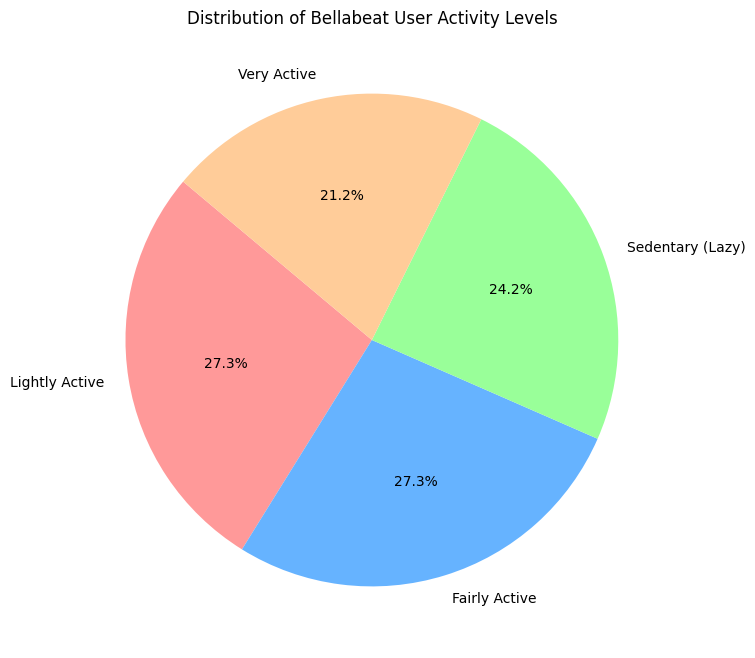

In [16]:
# Pick some nice professional colors
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

# Create the chart
plt.figure(figsize=(8,8))
plt.pie(user_type_counts, labels = user_type_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)

# Add a title so everyone knows what they are looking at
plt.title('Distribution of Bellabeat User Activity Levels')

# Show the chart
plt.show()

In [15]:
import matplotlib.pyplot as plt


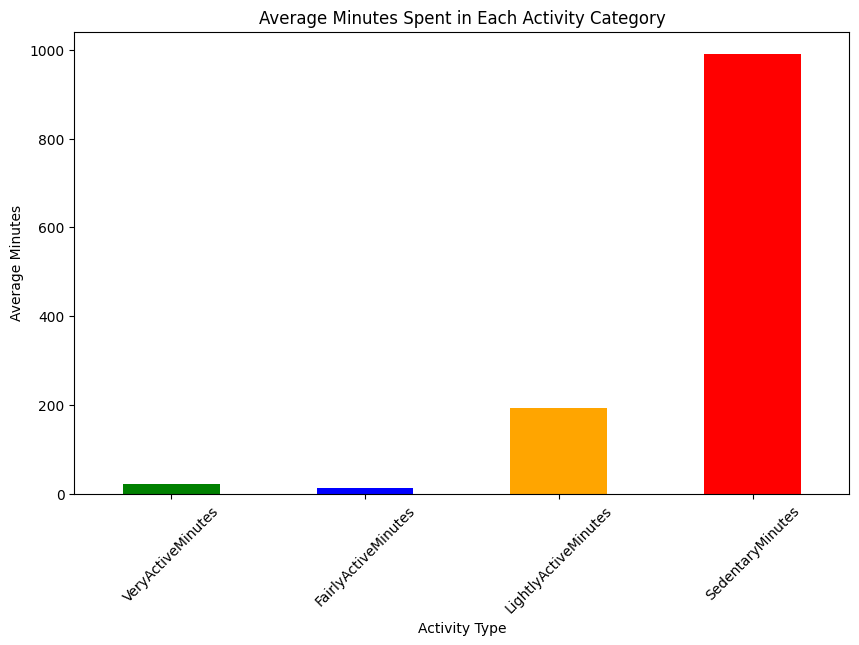

VeryActiveMinutes        21.164894
FairlyActiveMinutes      13.564894
LightlyActiveMinutes    192.812766
SedentaryMinutes        991.210638
dtype: float64


In [17]:
# Calculate the average of all types of minutes
minutes_summary = df_activity[['VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes','SedentaryMinutes']].mean()

# Create a Bar chart to show difference
plt.figure(figsize=(10,6))
minutes_summary.plot(kind='bar', color=['green','blue','orange','red'])

# Add labels
plt.title('Average Minutes Spent in Each Activity Category')
plt.xlabel('Activity Type')
plt.ylabel('Average Minutes')
plt.xticks(rotation=45)

# Show the plot
plt.show()

print(minutes_summary)


"Data shows the users spend the vast majority of their day being sedentary. This represents the huge opportunity for bellabeat to use 'Move Alerts' or notifications to encourage users to take short walks throughout the day"

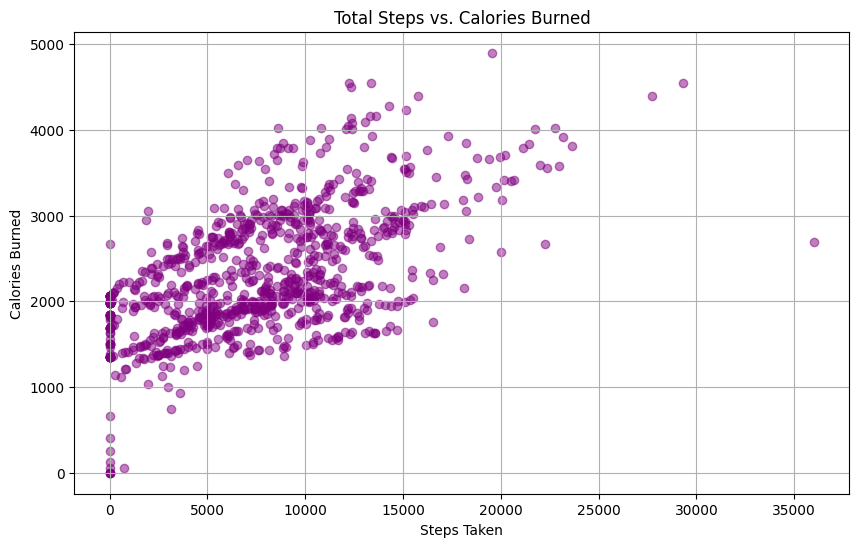

In [18]:
# Create the scatter plot
plt.figure(figsize=(10,6))
plt.scatter(df_activity['TotalSteps'],df_activity['Calories'], alpha=0.5, color='purple')

# Add labels so people know what they are looking at
plt.title('Total Steps vs. Calories Burned')
plt.xlabel('Steps Taken')
plt.ylabel('Calories Burned')
plt.grid(True)

# Show the chart
plt.show()

In [19]:
# Load the sleep data
sleep_path = '/content/drive/MyDrive/Bellabeat_Case_Study_Data/sleepDay_merged.csv'
df_sleep = pd.read_csv(sleep_path)

# Look at the first few rows to see what's inside
print(df_sleep.head())

# Check for any missing sleep data
print(df_sleep.isnull().sum())

           Id               SleepDay  TotalSleepRecords  TotalMinutesAsleep  \
0  1503960366  4/12/2016 12:00:00 AM                  1                 327   
1  1503960366  4/13/2016 12:00:00 AM                  2                 384   
2  1503960366  4/15/2016 12:00:00 AM                  1                 412   
3  1503960366  4/16/2016 12:00:00 AM                  2                 340   
4  1503960366  4/17/2016 12:00:00 AM                  1                 700   

   TotalTimeInBed  
0             346  
1             407  
2             442  
3             367  
4             712  
Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64


In [20]:
# We convert the sleepDay column into a proper date format
df_sleep['SleepDay'] = pd.to_datetime(df_sleep['SleepDay'])

# We rename it to 'ActivityDate' so it matches our other tabel exactly
df_sleep = df_sleep.rename(columns={'SleepyDay': 'ActivityDate'})

print("Dates are now ready to be matched")

Dates are now ready to be matched


/tmp/ipykernel_20703/2850822134.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sleep['SleepDay'] = pd.to_datetime(df_sleep['SleepDay'])


In [21]:
df_activity = df_activity.rename(columns={'ActivityDate': 'ActivityDate'})
df_sleep = df_sleep.rename(columns={'SleepDay': 'ActivityDate'})
combined_data = pd.merge(df_activity, df_sleep, on=['Id', 'ActivityDate'])
print(f"success! Merged table has {combined_data.shape[0]} rows.")
print(combined_data.head())

success! Merged table has 413 rows.
           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366   2016-04-12       13162           8.50             8.50   
1  1503960366   2016-04-13       10735           6.97             6.97   
2  1503960366   2016-04-15        9762           6.28             6.28   
3  1503960366   2016-04-16       12669           8.16             8.16   
4  1503960366   2016-04-17        9705           6.48             6.48   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                1.88                      0.55   
1                       0.0                1.57                      0.69   
2                       0.0                2.14                      1.26   
3                       0.0                2.71                      0.41   
4                       0.0                3.19                      0.78   

   LightActiveDistance  SedentaryActiveDistance  VeryAct

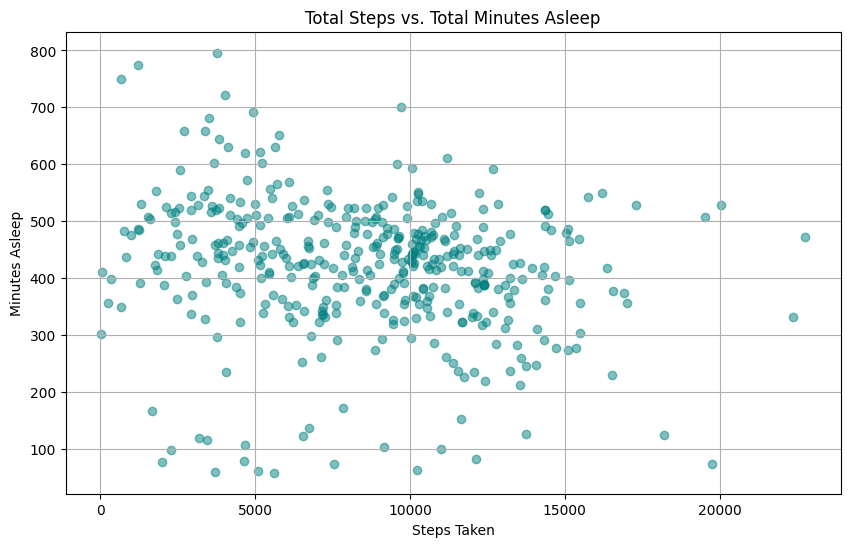

In [22]:
# Create a scatter plot to see this relationship
plt.figure(figsize=(10,6))
plt.scatter(combined_data['TotalSteps'], combined_data['TotalMinutesAsleep'], alpha=0.5, color='teal')

# Add labels
plt.title('Total Steps vs. Total Minutes Asleep')
plt.xlabel('Steps Taken')
plt.ylabel('Minutes Asleep')
plt.grid(True)

# Show the plot
plt.show()

"While steps and calories have strong link, the relationship between steps and sleep is more varied. This suggests that Bellabeat could offer more than just step tracking-they could offer 'Sleep Hygiene' tips or relaxing meditation to help users, regardless of how much they walked that day."